# CS229 final project notebook
Omry Bejerano, Yoni Aharon

In [2]:
# install sklearn 
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import zipfile
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [4]:
DRIVE_ZIP_PATH = "/home/jupyter/lending_club_data.zip"
LOCAL_EXTRACT_DIR = "/home/jupyter/lending_club"
DATA_PATH = os.path.join(LOCAL_EXTRACT_DIR, "accepted_2007_to_2018Q4.csv.gz")

# study setup
TRAIN_YEARS = [2016, 2017]
TEST_YEARS  = [2018]
ALPHA = 0.05
RANDOM_SEED = 42 # it's the answer to the universe so we thought it'd be a fitting seed number
np.random.seed(RANDOM_SEED)

In [5]:
# unzip data
if os.path.exists(DRIVE_ZIP_PATH):
    with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(LOCAL_EXTRACT_DIR)
    print("extracted")
else:
    print(f"not found: {DRIVE_ZIP_PATH}")

extracted


In [6]:
# columns known only after origination so they get dropped to avoid leakage
POST_ORIGINATION_COLS = [
    "total_pymnt", "total_pymnt_inv", "total_rec_prncp", "total_rec_int",
    "total_rec_late_fee", "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "last_pymnt_amnt", "next_pymnt_d",
    "last_fico_range_high", "last_fico_range_low", "out_prncp", "out_prncp_inv",
    "last_credit_pull_d", "debt_settlement_flag", "debt_settlement_flag_date",
    "settlement_status", "settlement_date", "settlement_amount",
    "settlement_percentage", "settlement_term", "deferral_term", "hardship_amount",
    "hardship_dpd", "hardship_end_date", "hardship_flag", "hardship_last_payment_amount",
    "hardship_length", "hardship_loan_status", "hardship_payoff_balance_amount",
    "hardship_reason", "hardship_start_date", "hardship_status", "hardship_type",
    "orig_projected_additional_accrued_interest", "payment_plan_start_date", "disbursement_method",
]

# needed for labels and loss but not as features
METADATA_COLS = ["funded_amnt", "total_pymnt", "loan_status", "issue_d"]

# ids and free text
ALWAYS_DROP_COLS = [
    "id", "member_id", "url", "title", "desc", "emp_title",
    "zip_code", "policy_code", "funded_amnt_inv", "application_type"
]

LABEL_MAP = {
    "Fully Paid": 0,
    "Charged Off": 1,
    "Default": 1,
    "Does not meet the credit policy. Status:Fully Paid": 0,
    "Does not meet the credit policy. Status:Charged Off": 1,
}

In [7]:
# load and keep settled loans in the cohort years then drop id and text cols
def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    print(f"  raw: {df.shape}")

    df = df[df["loan_status"].isin(LABEL_MAP.keys())].copy()
    print(f"  settled: {df.shape}")

    df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
    df["issue_year"] = df["issue_d"].dt.year
    df = df[df["issue_year"].isin(TRAIN_YEARS + TEST_YEARS)].copy()
    print(f"  2016-2018: {df.shape}")

    to_drop = [c for c in ALWAYS_DROP_COLS if c in df.columns]
    df.drop(columns=to_drop, inplace=True)
    return df

In [47]:
df_raw = load_data(DATA_PATH)

  raw: (2260701, 151)
  settled: (1348099, 151)
  2016-2018: (518744, 152)


In [48]:
# label plus dollar loss = funded minus paid floored at 0 for defaults only
def construct_labels(df: pd.DataFrame):
    y = df["loan_status"].map(LABEL_MAP).values.astype(float)
    dollar_loss = np.where(
        y == 1,
        np.maximum(df["funded_amnt"].values - df["total_pymnt"].values, 0),
        0.0,
    )
    print(f"  default rate: {y.mean():.2%}")
    print(f"  mean loss given default: ${dollar_loss[y == 1].mean():,.0f}")
    return y, dollar_loss

In [49]:
y_all, dollar_loss_all = construct_labels(df_raw)

  default rate: 22.42%
  mean loss given default: $9,047


In [50]:
def build_feature_matrix(df: pd.DataFrame):
    exclude = set(POST_ORIGINATION_COLS) | set(METADATA_COLS) | {"loan_status", "issue_d", "issue_year", "dollar_loss"}
    feature_cols = [c for c in df.columns if c not in exclude]
    X_df = df[feature_cols].copy()

    # flag missingness first since a missing value here is informative and imputation would hide it
    INDICATOR_COLS = [
        'emp_length', 'dti', 'revol_util',
        'mths_since_last_delinq', 'mths_since_last_record',
        'mths_since_last_major_derog'
    ]
    for col in INDICATOR_COLS:
        if col in X_df.columns:
            X_df[f'{col}_missing'] = X_df[col].isna().astype(float)

    # drop cols that are basically all missing
    high_miss = [c for c in X_df.columns if X_df[c].isna().mean() > 0.90]
    X_df.drop(columns=high_miss, inplace=True, errors='ignore')

    # drop the sparse joint-applicant block
    joint_cols = [c for c in X_df.columns if c.startswith('sec_app_')]
    X_df.drop(columns=joint_cols, inplace=True, errors='ignore')

    # parse the string-coded numerics into floats
    if "term" in X_df.columns:
        X_df["term"] = X_df["term"].str.extract(r"(\d+)").astype(float)
    if "int_rate" in X_df.columns and X_df["int_rate"].dtype == object:
        X_df["int_rate"] = X_df["int_rate"].str.replace("%", "").astype(float)
    if "revol_util" in X_df.columns and X_df["revol_util"].dtype == object:
        X_df["revol_util"] = X_df["revol_util"].str.replace("%", "").astype(float)

    if "emp_length" in X_df.columns:
        emp_map = {"< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
                   "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9, "10+ years": 10}
        X_df["emp_length"] = X_df["emp_length"].map(emp_map)

    # earliest credit line becomes months of history at issue
    if "earliest_cr_line" in X_df.columns and "issue_d" in df.columns:
        ecl = pd.to_datetime(X_df["earliest_cr_line"], format="%b-%Y", errors="coerce")
        issue = pd.to_datetime(df["issue_d"], errors="coerce")
        X_df["credit_history_months"] = (issue.dt.year - ecl.dt.year) * 12 + (issue.dt.month - ecl.dt.month)
        X_df.drop(columns=["earliest_cr_line"], inplace=True)

    # one-hot the categoricals then median-fill whatever's left
    cat_cols = X_df.select_dtypes(include=["object", "category"]).columns.tolist()
    X_encoded = pd.get_dummies(X_df, columns=cat_cols, drop_first=True)
    X_encoded = X_encoded.fillna(X_encoded.median(numeric_only=True))

    return X_encoded.values.astype(float), X_encoded.columns.tolist()

In [51]:
X_all, feature_names = build_feature_matrix(df_raw)
print(f"design matrix: {X_all.shape}")

design matrix: (518744, 190)


In [52]:
# time split with train on 2016-17 and test on 2018
train_mask = df_raw["issue_year"].isin(TRAIN_YEARS).values
test_mask  = df_raw["issue_year"].isin(TEST_YEARS).values

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]
dl_test = dollar_loss_all[test_mask]

print(f"  train: {X_train.shape}")
print(f"  test:  {X_test.shape}")

  train: (462426, 190)
  test:  (56318, 190)


In [53]:
# es@5% is mean dollar loss in the top-5% riskiest and dwr is the share of total dollar loss in the top decile
def expected_shortfall(y_true, y_prob, dollar_loss, alpha=ALPHA):
    n = len(y_prob)
    k = max(1, int(np.ceil(alpha * n)))
    top_k_idx = np.argsort(y_prob)[::-1][:k]      # k riskiest by predicted prob
    return dollar_loss[top_k_idx].mean()

def dollar_weighted_recall(y_true, y_prob, dollar_loss, top_frac=0.10):
    n = len(y_prob)
    k = max(1, int(np.ceil(top_frac * n)))
    top_k_idx = np.argsort(y_prob)[::-1][:k]
    total_loss = dollar_loss.sum()
    return dollar_loss[top_k_idx].sum() / total_loss if total_loss > 0 else 0.0

def evaluate(model_name, y_true, y_prob, dollar_loss):
    y_pred = (y_prob >= 0.5).astype(int)
    auc = roc_auc_score(y_true, y_prob)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    es  = expected_shortfall(y_true, y_prob, dollar_loss)
    dwr = dollar_weighted_recall(y_true, y_prob, dollar_loss)
    print(f"{model_name}: auc {auc:.4f}, f1 {f1:.4f}, es@5% ${es:,.0f}, dwr {dwr:.2%}")
    return {"model": model_name, "auc": auc, "f1": f1, "es5": es, "dwr": dwr}

In [54]:
# scale then fit a plain logistic regression baseline
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_train)
X_te_scaled = scaler.transform(X_test)

lr_baseline = LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs", random_state=RANDOM_SEED)
lr_baseline.fit(X_tr_scaled, y_train)

y_prob_tr_bs = lr_baseline.predict_proba(X_tr_scaled)[:, 1]
y_prob_te_bs = lr_baseline.predict_proba(X_te_scaled)[:, 1]

# train row passes a zero loss vector since we only want its auc and f1
_ = evaluate("LR train", y_train, y_prob_tr_bs, np.zeros(len(y_train)))
baseline_metrics = evaluate("LR test (2018)", y_test, y_prob_te_bs, dl_test)

LR train: auc 0.7219, f1 0.2125, es@5% $0, dwr 0.00%
LR test (2018): auc 0.7188, f1 0.1721, es@5% $7,478, dwr 28.99%


In [55]:
# sigmoid and a numerically stable per-example logistic loss
def sigmoid(z):
    return np.where(z >= 0, 1 / (1 + np.exp(-z)), np.exp(z) / (1 + np.exp(z)))

def logistic_loss_per_example(theta, X, y):
    z = X @ theta
    return np.log1p(np.exp(-np.abs(z))) + np.maximum(0, -z * (2 * y - 1))

# rockafellar-uryasev cvar objective eta + (1/alpha n) sum of (L_i - eta)_+
def cvar_objective(theta, eta, X, y, alpha, lambda_reg=1e-4):
    n = len(y)
    losses = logistic_loss_per_example(theta, X, y)
    shortfall = np.maximum(losses - eta, 0.0)
    return eta + shortfall.sum() / (alpha * n) + (0.5 * lambda_reg * np.dot(theta, theta))

def cvar_subgradients(theta, eta, X, y, alpha, lambda_reg=1e-4):
    n = len(y)
    losses = logistic_loss_per_example(theta, X, y)
    active = losses > eta                          # examples above the threshold count toward the gradient
    g_eta = 1.0 - (active.sum() / (alpha * n))
    z = X @ theta
    residuals_active = (sigmoid(z) - y) * active
    g_theta = (X.T @ residuals_active / (alpha * n)) + (lambda_reg * theta)
    return g_theta, g_eta

In [56]:
# plain sgd on (theta eta) with a c/sqrt(t) step size and eta seeded at the (1-alpha)-quantile
def sgd_cvar(X, y, alpha, n_epochs=50, batch_size=256, lr_init=0.1, lambda_reg=1e-4):
    n, d = X.shape
    theta = np.zeros(d)
    init_losses = logistic_loss_per_example(theta, X, y)
    eta = np.quantile(init_losses, 1 - alpha)

    history = []
    t = 0
    for epoch in range(n_epochs):
        perm = np.random.permutation(n)
        for start in range(0, n, batch_size):
            batch_idx = perm[start : start + batch_size]
            X_b, y_b = X[batch_idx], y[batch_idx]
            t += 1
            lr = lr_init / np.sqrt(t)
            g_theta, g_eta = cvar_subgradients(theta, eta, X_b, y_b, alpha, lambda_reg)
            theta -= lr * g_theta
            eta   -= lr * g_eta
        history.append(cvar_objective(theta, eta, X, y, alpha, lambda_reg))   # full-data objective once per epoch
    return theta, eta, history

In [57]:
# add a bias column then sweep alpha for the log-loss cvar
X_tr_b = np.hstack([X_tr_scaled, np.ones((X_tr_scaled.shape[0], 1))])
X_te_b = np.hstack([X_te_scaled, np.ones((X_te_scaled.shape[0], 1))])

alpha_values = [1.0, 0.5, 0.25, 0.1, 0.05]
results_log = [baseline_metrics]
loss_convergence_histories = {}

for a in alpha_values:
    print(f"alpha={a}...")
    theta_learned, eta_learned, history_log = sgd_cvar(
        X_tr_b, y_train, alpha=a, n_epochs=50, batch_size=512, lr_init=0.1, lambda_reg=1e-4
    )
    y_prob_cvar = sigmoid(X_te_b @ theta_learned)
    metrics_cvar = evaluate(f"CVaR-Logistic alpha={a}", y_test, y_prob_cvar, dl_test)
    results_log.append(metrics_cvar)
    loss_convergence_histories[f"alpha={a}"] = history_log

alpha=1.0...
CVaR-Logistic alpha=1.0: auc 0.7168, f1 0.1870, es@5% $7,443, dwr 28.87%
alpha=0.5...
CVaR-Logistic alpha=0.5: auc 0.5998, f1 0.0349, es@5% $4,907, dwr 18.45%
alpha=0.25...
CVaR-Logistic alpha=0.25: auc 0.5919, f1 0.2216, es@5% $4,190, dwr 17.08%
alpha=0.1...
CVaR-Logistic alpha=0.1: auc 0.4623, f1 0.1917, es@5% $2,649, dwr 10.61%
alpha=0.05...
CVaR-Logistic alpha=0.05: auc 0.5842, f1 0.2192, es@5% $4,028, dwr 16.09%


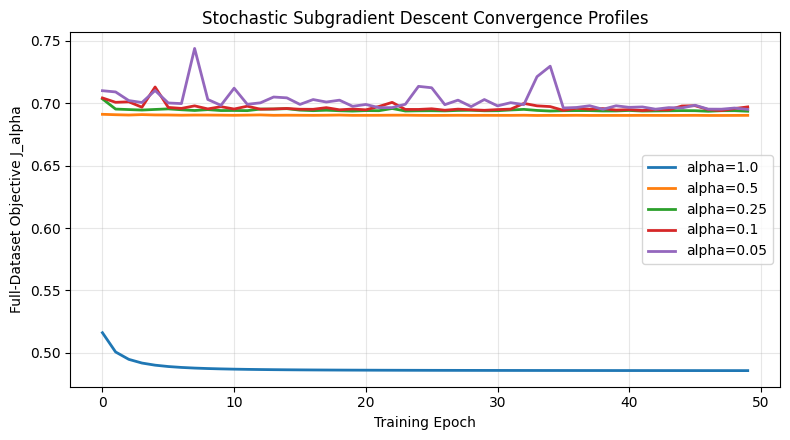

In [58]:
# sgd convergence per alpha
plt.figure(figsize=(8, 4.5))
for label, hist in loss_convergence_histories.items():
    plt.plot(hist, label=label, lw=2)
plt.xlabel("Training Epoch")
plt.ylabel("Full-Dataset Objective J_alpha")
plt.title("Stochastic Subgradient Descent Convergence Profiles")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [59]:
# log-loss cvar sweep table
summary_df = pd.DataFrame(results_log).set_index("model")
summary_df["es5"] = summary_df["es5"].map("${:,.0f}".format)
summary_df["dwr"] = summary_df["dwr"].map("{:.1%}".format)
print(summary_df.to_string())

                               auc        f1     es5    dwr
model                                                      
LR test (2018)            0.718802  0.172109  $7,478  29.0%
CVaR-Logistic alpha=1.0   0.716774  0.186950  $7,443  28.9%
CVaR-Logistic alpha=0.5   0.599839  0.034896  $4,907  18.5%
CVaR-Logistic alpha=0.25  0.591859  0.221631  $4,190  17.1%
CVaR-Logistic alpha=0.1   0.462309  0.191657  $2,649  10.6%
CVaR-Logistic alpha=0.05  0.584235  0.219164  $4,028  16.1%


In [60]:
# synthetic 2d check with one tight minority cluster where we draw the boundary at a few alphas
def plot_synthetic_boundaries(alpha_values=(1.0, 0.25, 0.05)):
    np.random.seed(RANDOM_SEED)
    n0, n1 = 800, 80
    X0 = np.random.randn(n0, 2) * np.array([1.0, 0.5]) + np.array([0.0, 0.0])
    X1 = np.random.randn(n1, 2) * np.array([0.5, 0.5]) + np.array([2.5, 1.5])

    X_syn = np.vstack([X0, X1])
    y_syn = np.concatenate([np.zeros(n0), np.ones(n1)])

    scaler_syn = StandardScaler()
    X_syn_sc = scaler_syn.fit_transform(X_syn)
    X_syn_b = np.hstack([X_syn_sc, np.ones((len(X_syn_sc), 1))])

    fig, axes = plt.subplots(1, len(alpha_values), figsize=(5 * len(alpha_values), 4))
    if len(alpha_values) == 1: axes = [axes]

    # grid the feature plane so we can contour the predicted prob
    x_grid = np.linspace(-3, 3, 200)
    y_grid = np.linspace(-3, 3, 200)
    xx, yy = np.meshgrid(x_grid, y_grid)
    grid_flat = np.c_[xx.ravel(), yy.ravel(), np.ones(xx.size)]
    colors = ["steelblue", "firebrick"]

    for ax, alpha in zip(axes, alpha_values):
        theta_syn, eta_syn, _ = sgd_cvar(
            X_syn_b, y_syn, alpha=alpha, n_epochs=200, batch_size=64, lr_init=0.3, lambda_reg=1e-3
        )
        z_grid = grid_flat @ theta_syn
        prob_grid = sigmoid(z_grid).reshape(xx.shape)

        ax.contourf(xx, yy, prob_grid, levels=[0, 0.5, 1], colors=["#d4e6f1", "#fadbd8"], alpha=0.6)
        ax.contour(xx, yy, prob_grid, levels=[0.5], colors="black", linewidths=1.5)

        for cls, clr, label in [(0, colors[0], "Non-default"), (1, colors[1], "Default")]:
            mask = y_syn == cls
            pts = X_syn_sc[mask]
            ax.scatter(pts[:, 0], pts[:, 1], c=clr, s=12, alpha=0.7, label=label)

        ax.set_title(f"alpha = {alpha}")
        ax.legend(fontsize=8)
        ax.set_xlabel("Feature 1 (scaled)")
        ax.set_ylabel("Feature 2 (scaled)")

    fig.suptitle("Decision boundary shifts as alpha decreases\n(boundary moves toward minority class)", y=1.02)
    plt.tight_layout()
    plt.show()

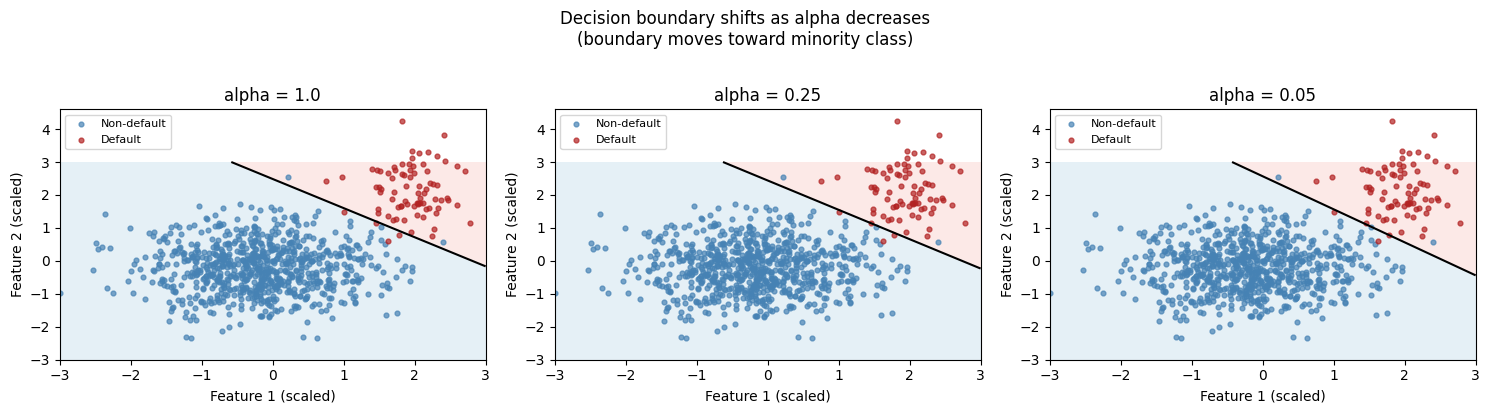

In [61]:
plot_synthetic_boundaries(alpha_values=(1.0, 0.25, 0.05))

# Part 2: Extended experiments
Dollar-weighted cvar, two more solvers, a solver comparison, the class baselines, and the calibration, error, and frontier analysis.

Run part 1 first so X_tr_b, X_te_b, y_train, y_test, dl_test, scaler, df_raw and the metric functions exist.

## Funded amounts
Pulling each loan's funded amount for the loss weighting and the error analysis, on the same train/test masks. It's known at origination so it isn't leakage.

In [62]:
# funded amounts on the same masks normalized to mean 1 so the lambda_reg scale is unchanged
funded_all   = df_raw["funded_amnt"].values.astype(float)
funded_train = funded_all[train_mask]
funded_test  = funded_all[test_mask]

w_train = funded_train / funded_train.mean()

print(f"funded train mean ${funded_train.mean():,.0f}, min ${funded_train.min():,.0f}, max ${funded_train.max():,.0f}")
print(f"weights mean {w_train.mean():.3f}, max {w_train.max():.2f}")

funded train mean $14,406, min $1,000, max $40,000
weights mean 1.000, max 2.78


## Dollar-loss-weighted CVaR
The log-loss tail is mostly small hard-to-classify loans rather than the big-dollar defaults, so we weight each per-example loss by its normalized funded amount, $\tilde{L}_i(\theta) = w_i L_i(\theta)$ with $w_i = \texttt{funded\_amnt}_i / \bar{w}$. Same objective and subgradients, just a rescaled loss vector, and weights=None recovers the original (checked below).

In [63]:
# weighted versions of the cvar math where weights=None reduces to the originals
def logistic_loss_weighted(theta, X, y, weights=None):
    base = logistic_loss_per_example(theta, X, y)
    return base if weights is None else weights * base

def cvar_objective_w(theta, eta, X, y, alpha, lambda_reg=1e-4, weights=None):
    n = len(y)
    losses = logistic_loss_weighted(theta, X, y, weights)
    shortfall = np.maximum(losses - eta, 0.0)
    return eta + shortfall.sum() / (alpha * n) + 0.5 * lambda_reg * np.dot(theta, theta)

def cvar_subgradients_w(theta, eta, X, y, alpha, lambda_reg=1e-4, weights=None):
    n = len(y)
    z = X @ theta                                  # compute once and reuse for loss and gradient
    base = np.log1p(np.exp(-np.abs(z))) + np.maximum(0, -z * (2 * y - 1))
    losses = base if weights is None else weights * base
    active = losses > eta
    g_eta = 1.0 - (active.sum() / (alpha * n))
    per_example = (sigmoid(z) - y) * active
    if weights is not None:
        per_example = per_example * weights
    g_theta = (X.T @ per_example / (alpha * n)) + (lambda_reg * theta)
    return g_theta, g_eta

# check weights=None matches the unweighted versions
_theta = np.random.randn(X_tr_b.shape[1]) * 0.01
_eta   = 0.5
_o1 = cvar_objective(_theta, _eta, X_tr_b[:1000], y_train[:1000], 0.1)
_o2 = cvar_objective_w(_theta, _eta, X_tr_b[:1000], y_train[:1000], 0.1, weights=None)
_g1 = cvar_subgradients(_theta, _eta, X_tr_b[:1000], y_train[:1000], 0.1)[0]
_g2 = cvar_subgradients_w(_theta, _eta, X_tr_b[:1000], y_train[:1000], 0.1, weights=None)[0]
print(f"objective match: {np.isclose(_o1, _o2)}")
print(f"subgradient max diff: {np.abs(_g1 - _g2).max():.2e}")

objective match: True
subgradient max diff: 0.00e+00


In [64]:
# same sgd but eta is closed-form refreshed once per epoch to the (1-alpha)-quantile of the
# current losses which is its minimizer so it doesn't have to drift there via gradient steps
# also takes a warm start
def sgd_cvar_w(X, y, alpha, weights=None, n_epochs=20, batch_size=4096,
               lr_init=0.1, lambda_reg=1e-4, theta_init=None,
               log_every=2):
    n, d = X.shape
    theta = np.zeros(d) if theta_init is None else theta_init.copy()
    eta = np.quantile(logistic_loss_weighted(theta, X, y, weights), 1 - alpha)

    history, t = [], 0
    for epoch in range(n_epochs):
        perm = np.random.permutation(n)
        for start in range(0, n, batch_size):
            idx = perm[start : start + batch_size]
            w_b = None if weights is None else weights[idx]
            t += 1
            lr = lr_init / np.sqrt(t)
            # theta step only with eta held fixed within the epoch
            g_theta, _ = cvar_subgradients_w(theta, eta, X[idx], y[idx],
                                             alpha, lambda_reg, w_b)
            theta -= lr * g_theta

        # refresh eta to the (1-alpha)-quantile
        losses_full = logistic_loss_weighted(theta, X, y, weights)
        eta = np.quantile(losses_full, 1 - alpha)

        # a full pass for logging is expensive so only do it occasionally
        if (epoch + 1) % log_every == 0 or epoch == n_epochs - 1:
            history.append(cvar_objective_w(theta, eta, X, y, alpha, lambda_reg, weights))
    return theta, eta, history

In [65]:
# dollar-weighted sweep warm-started from the lr baseline which is the alpha=1 optimum
print("dollar-weighted cvar")
theta_warm = np.concatenate([lr_baseline.coef_.ravel(), [lr_baseline.intercept_[0]]])

results_weighted = []
hist_weighted = {}
dollar_cvar_preds = {}   # keep per-alpha test preds for the later analysis

for a in alpha_values:
    print(f"alpha={a}...")
    theta_w, eta_w, hist_w = sgd_cvar_w(
        X_tr_b, y_train, alpha=a, weights=w_train,
        n_epochs=40, batch_size=4096, lr_init=0.1, lambda_reg=1e-4,
        theta_init=theta_warm
    )
    y_prob_w = sigmoid(X_te_b @ theta_w)
    dollar_cvar_preds[a] = y_prob_w
    m = evaluate(f"Dollar-CVaR alpha={a}", y_test, y_prob_w, dl_test)
    results_weighted.append(m)
    hist_weighted[f"alpha={a}"] = hist_w

dollar-weighted cvar
alpha=1.0...
Dollar-CVaR alpha=1.0: auc 0.7195, f1 0.1755, es@5% $7,543, dwr 29.17%
alpha=0.5...
Dollar-CVaR alpha=0.5: auc 0.6771, f1 0.1750, es@5% $4,048, dwr 15.99%
alpha=0.25...
Dollar-CVaR alpha=0.25: auc 0.5487, f1 0.2525, es@5% $1,211, dwr 5.51%
alpha=0.1...
Dollar-CVaR alpha=0.1: auc 0.4939, f1 0.2518, es@5% $480, dwr 2.55%
alpha=0.05...
Dollar-CVaR alpha=0.05: auc 0.6163, f1 0.2987, es@5% $3,026, dwr 12.01%


## Solver 1: deterministic subgradient
Same subgradient as sgd but over the full dataset each step, so no minibatch noise and a smooth curve, at the cost of a full pass per step.

In [66]:
# full-batch subgradient with lr matched to sgd so a bigger step doesn't overshoot the warm start
def det_subgradient_cvar(X, y, alpha, weights=None, n_iters=80,
                         lr_init=0.1, lambda_reg=1e-4, theta_init=None,
                         eta_refresh_every=5, record_time=False):
    import time
    n, d = X.shape
    theta = np.zeros(d) if theta_init is None else theta_init.copy()
    eta = np.quantile(logistic_loss_weighted(theta, X, y, weights), 1 - alpha)

    history, times = [], []
    t0 = time.time()
    for t in range(1, n_iters + 1):
        lr = lr_init / np.sqrt(t)
        g_theta, _ = cvar_subgradients_w(theta, eta, X, y, alpha, lambda_reg, weights)
        theta -= lr * g_theta
        # refresh eta every few steps rather than every step
        if t % eta_refresh_every == 0 or t == n_iters:
            eta = np.quantile(logistic_loss_weighted(theta, X, y, weights), 1 - alpha)
        history.append(cvar_objective_w(theta, eta, X, y, alpha, lambda_reg, weights))
        if record_time:
            times.append(time.time() - t0)
    return (theta, eta, history, times) if record_time else (theta, eta, history)

## Solver 2: Moreau-smoothed proximal
Replacing the hinge $(z)_+$ with its moreau envelope $h_\mu$ makes the objective differentiable, so we run gradient descent with nesterov momentum and anneal $\mu = \mu_0/\sqrt{t}$. Gradient-checked before running.

In [67]:
# moreau envelope of max(0 z) and its derivative as a smooth stand-in for the hinge
def moreau_envelope(z, mu):
    return np.where(z <= 0, 0.0, np.where(z <= mu, z**2 / (2*mu), z - mu/2))

def moreau_grad(z, mu):
    return np.where(z <= 0, 0.0, np.where(z <= mu, z / mu, 1.0))

# smoothed objective and gradient
def smooth_cvar_objective(theta, eta, X, y, alpha, mu, lambda_reg=1e-4, weights=None):
    n = len(y)
    losses = logistic_loss_weighted(theta, X, y, weights)
    smoothed = moreau_envelope(losses - eta, mu)
    return eta + smoothed.sum() / (alpha * n) + 0.5 * lambda_reg * np.dot(theta, theta)

def smooth_cvar_gradients(theta, eta, X, y, alpha, mu, lambda_reg=1e-4, weights=None):
    n = len(y)
    losses = logistic_loss_weighted(theta, X, y, weights)
    g = moreau_grad(losses - eta, mu)              # smooth gate in [0,1] replacing the hard active mask
    g_eta = 1.0 - g.sum() / (alpha * n)
    z = X @ theta
    chain = (sigmoid(z) - y) * g
    if weights is not None:
        chain = chain * weights
    g_theta = X.T @ chain / (alpha * n) + lambda_reg * theta
    return g_theta, g_eta

In [68]:
# finite-difference gradient check on a small slice
_X, _y = X_tr_b[:500], y_train[:500]
_theta = np.random.randn(_X.shape[1]) * 0.01
_eta, _mu, _a = 0.4, 0.1, 0.1
_ga, _ge = smooth_cvar_gradients(_theta, _eta, _X, _y, _a, _mu)

eps = 1e-6
ok = True
check_idx = [j for j in [0, 5, 50, 200, _X.shape[1]-1] if j < _X.shape[1]]
for j in check_idx:
    # central difference for one theta coord
    tp = _theta.copy(); tp[j] += eps
    tm = _theta.copy(); tm[j] -= eps
    num = (smooth_cvar_objective(tp, _eta, _X, _y, _a, _mu)
           - smooth_cvar_objective(tm, _eta, _X, _y, _a, _mu)) / (2*eps)
    if not np.isclose(num, _ga[j], atol=1e-4): ok = False
    print(f"theta[{j:3d}]  analytic {_ga[j]:+.6f}  numerical {num:+.6f}")
# same check for eta
num_eta = (smooth_cvar_objective(_theta, _eta+eps, _X, _y, _a, _mu)
           - smooth_cvar_objective(_theta, _eta-eps, _X, _y, _a, _mu)) / (2*eps)
print(f"eta        analytic {_ge:+.6f}  numerical {num_eta:+.6f}")
print("gradient check:", "PASS" if ok and np.isclose(num_eta, _ge, atol=1e-4) else "CHECK")

theta[  0]  analytic -0.156513  numerical -0.156513
theta[  5]  analytic +0.323299  numerical +0.323299
theta[ 50]  analytic -0.060414  numerical -0.060414
theta[190]  analytic +2.411527  numerical +2.411527
eta        analytic -8.924397  numerical -8.924397
gradient check: PASS


In [69]:
# nesterov momentum on the smoothed objective and anneal mu but floor it since the gradient is
# (1/mu)-lipschitz and letting mu hit 0 makes the fixed step diverge
def proximal_cvar(X, y, alpha, weights=None, n_iters=80, lr=0.1,
                  mu_init=1.0, mu_min=0.05, momentum=0.9, lambda_reg=1e-4,
                  theta_init=None, record_time=False):
    import time
    n, d = X.shape
    theta = np.zeros(d) if theta_init is None else theta_init.copy()
    eta = np.quantile(logistic_loss_weighted(theta, X, y, weights), 1 - alpha)

    v_theta = np.zeros(d); v_eta = 0.0
    history, times = [], []
    t0 = time.time()
    for t in range(1, n_iters + 1):
        mu = max(mu_init / np.sqrt(t), mu_min)
        # look-ahead point for nesterov
        look_theta = theta + momentum * v_theta
        look_eta   = eta + momentum * v_eta
        g_theta, g_eta = smooth_cvar_gradients(look_theta, look_eta, X, y,
                                               alpha, mu, lambda_reg, weights)
        v_theta = momentum * v_theta - lr * g_theta
        v_eta   = momentum * v_eta   - lr * g_eta
        theta += v_theta
        eta   += v_eta
        history.append(cvar_objective_w(theta, eta, X, y, alpha, lambda_reg, weights))
        if record_time:
            times.append(time.time() - t0)
    return (theta, eta, history, times) if record_time else (theta, eta, history)

## Solver comparison
All three on the same problem and init, logging the true non-smooth objective, compared per iteration and per wallclock second.

In [70]:
# compare the three solvers on a 100k subsample from one warm start looking at relative behavior not final accuracy
import time
COMPARE_ALPHA = 0.1
SUB_N = 100_000
print(f"solver comparison at alpha={COMPARE_ALPHA} on {SUB_N:,} loans")

rng = np.random.default_rng(RANDOM_SEED)
sub_idx = rng.choice(len(y_train), size=min(SUB_N, len(y_train)), replace=False)
X_sub, y_sub, w_sub = X_tr_b[sub_idx], y_train[sub_idx], w_train[sub_idx]

theta_warm = np.concatenate([lr_baseline.coef_.ravel(), [lr_baseline.intercept_[0]]])

t0 = time.time()
_, _, sgd_hist = sgd_cvar_w(X_sub, y_sub, alpha=COMPARE_ALPHA, weights=w_sub,
                            n_epochs=20, batch_size=4096, lr_init=0.1,
                            theta_init=theta_warm, log_every=1)
sgd_time = time.time() - t0
# sgd logs per epoch not per second so spread its times evenly for the wallclock plot
sgd_times = np.linspace(sgd_time/len(sgd_hist), sgd_time, len(sgd_hist))

_, _, det_hist, det_times = det_subgradient_cvar(
    X_sub, y_sub, alpha=COMPARE_ALPHA, weights=w_sub,
    n_iters=80, lr_init=0.1, theta_init=theta_warm, record_time=True)

# lower momentum on the proximal run calms the oscillation
_, _, prox_hist, prox_times = proximal_cvar(
    X_sub, y_sub, alpha=COMPARE_ALPHA, weights=w_sub,
    n_iters=80, lr=0.1, mu_init=1.0, momentum=0.7,
    theta_init=theta_warm, record_time=True)

print(f"sgd final  {sgd_hist[-1]:.5f}  ({sgd_time:.1f}s)")
print(f"det final  {det_hist[-1]:.5f}  ({det_times[-1]:.1f}s)")
print(f"prox final {prox_hist[-1]:.5f}  ({prox_times[-1]:.1f}s)")

solver comparison at alpha=0.1 on 100,000 loans
sgd final  1.53462  (2.4s)
det final  1.62193  (3.0s)
prox final 1.81217  (3.2s)


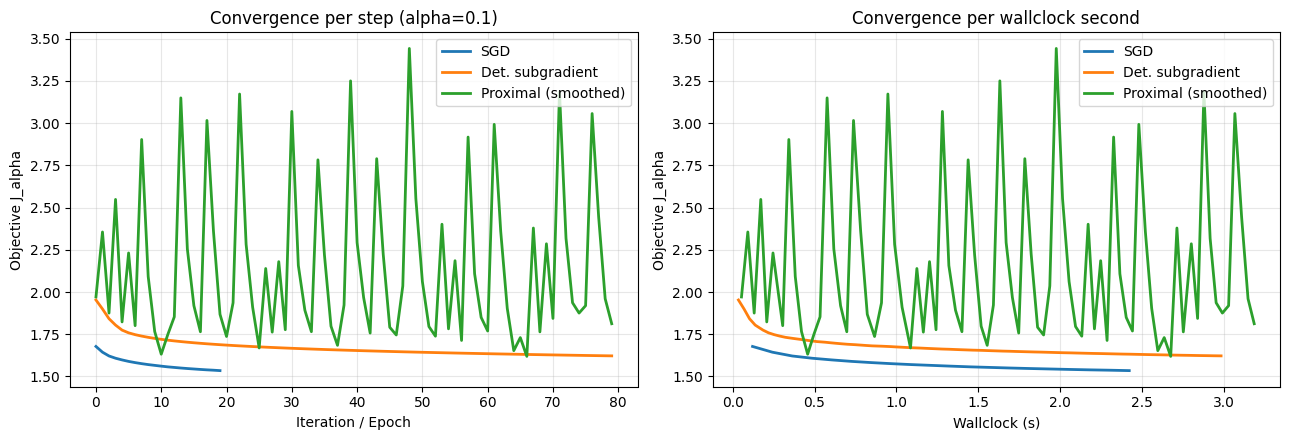

In [71]:
# convergence per step on the left and per wallclock on the right
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(sgd_hist,  label="SGD",                lw=2)
ax1.plot(det_hist,  label="Det. subgradient",   lw=2)
ax1.plot(prox_hist, label="Proximal (smoothed)", lw=2)
ax1.set_xlabel("Iteration / Epoch"); ax1.set_ylabel("Objective J_alpha")
ax1.set_title(f"Convergence per step (alpha={COMPARE_ALPHA})")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(sgd_times,  sgd_hist,  label="SGD",                lw=2)
ax2.plot(det_times,  det_hist,  label="Det. subgradient",   lw=2)
ax2.plot(prox_times, prox_hist, label="Proximal (smoothed)", lw=2)
ax2.set_xlabel("Wallclock (s)"); ax2.set_ylabel("Objective J_alpha")
ax2.set_title("Convergence per wallclock second")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("solver_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Baselines
Cost-sensitive lr (fixed funded-amount weights), gda (shared covariance, linear boundary), qda (per-class covariance, quadratic boundary), random forest (nonlinear ceiling), and pca (also reused as the subspace for a better-conditioned qda).

In [72]:
# cost-sensitive lr with sample weights set to funded amount
from sklearn.linear_model import LogisticRegression as _LR
cs_lr = _LR(C=1.0, max_iter=1000, solver="lbfgs", random_state=RANDOM_SEED)
cs_lr.fit(X_tr_scaled, y_train, sample_weight=w_train)
y_prob_cs = cs_lr.predict_proba(X_te_scaled)[:, 1]
cs_metrics = evaluate("Cost-Sensitive LR (funded-weighted)", y_test, y_prob_cs, dl_test)

Cost-Sensitive LR (funded-weighted): auc 0.7196, f1 0.1736, es@5% $7,538, dwr 28.96%


In [73]:
# gda from scratch with a shared covariance
def fit_gda(X, y):
    n, d = X.shape
    phi = y.mean()
    mu0 = X[y == 0].mean(axis=0)
    mu1 = X[y == 1].mean(axis=0)
    Xc = X.copy()
    Xc[y == 0] -= mu0
    Xc[y == 1] -= mu1
    Sigma = (Xc.T @ Xc) / n
    Sigma += 1e-4 * np.eye(d)                       # ridge so the high-dim covariance inverts cleanly
    return phi, mu0, mu1, Sigma

def gda_proba(X, phi, mu0, mu1, Sigma):
    Sinv = np.linalg.inv(Sigma)
    d0 = X - mu0; d1 = X - mu1
    # per-row mahalanobis distance without the slow 3-way einsum
    q0 = -0.5 * np.sum((d0 @ Sinv) * d0, axis=1)
    q1 = -0.5 * np.sum((d1 @ Sinv) * d1, axis=1)
    log_p1 = q1 + np.log(phi)
    log_p0 = q0 + np.log(1 - phi)
    # softmax over the two classes shifted by the max for stability
    m = np.maximum(log_p0, log_p1)
    return np.exp(log_p1 - m) / (np.exp(log_p0 - m) + np.exp(log_p1 - m))

phi, mu0, mu1, Sigma = fit_gda(X_tr_scaled, y_train)
y_prob_gda = gda_proba(X_te_scaled, phi, mu0, mu1, Sigma)
gda_metrics = evaluate("GDA (shared covariance)", y_test, y_prob_gda, dl_test)

GDA (shared covariance): auc 0.7173, f1 0.2043, es@5% $7,245, dwr 27.53%


In [74]:
# random forest as a nonlinear ceiling
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED,
                            n_jobs=-1, max_depth=None, min_samples_leaf=20)
rf.fit(X_tr_scaled, y_train)
y_prob_rf = rf.predict_proba(X_te_scaled)[:, 1]
rf_metrics = evaluate("Random Forest", y_test, y_prob_rf, dl_test)

Random Forest: auc 0.7198, f1 0.0993, es@5% $6,973, dwr 27.66%


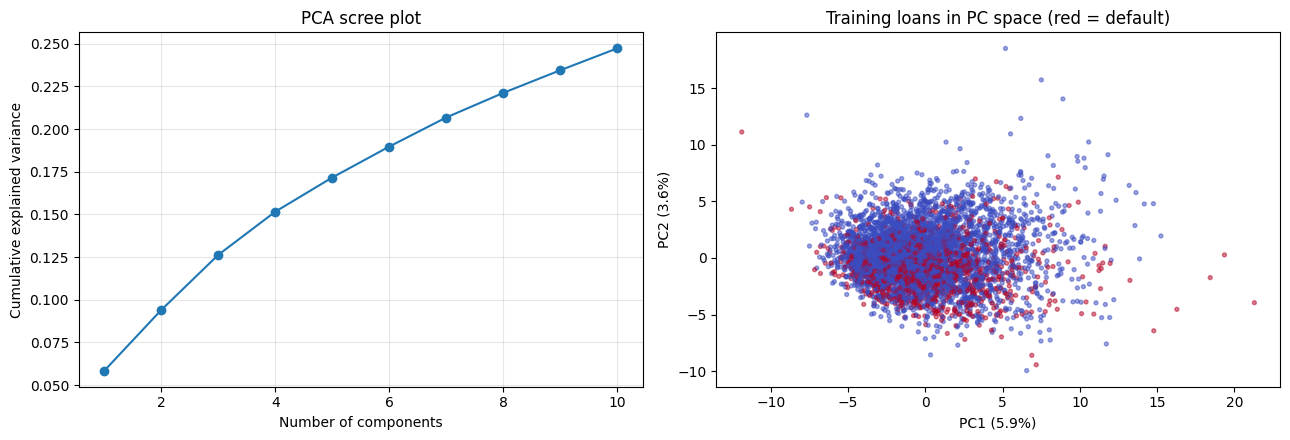

first two components explain 9.4%


In [75]:
# pca scree plot and a 2d scatter
from sklearn.decomposition import PCA
pca = PCA(n_components=10, random_state=RANDOM_SEED)
Z_tr = pca.fit_transform(X_tr_scaled)
evr = pca.explained_variance_ratio_

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.5))
axA.plot(np.arange(1, 11), np.cumsum(evr), "o-")
axA.set_xlabel("Number of components"); axA.set_ylabel("Cumulative explained variance")
axA.set_title("PCA scree plot"); axA.grid(True, alpha=0.3)
# subsample the scatter so it renders fast
idx = np.random.choice(len(Z_tr), size=min(5000, len(Z_tr)), replace=False)
sc = axB.scatter(Z_tr[idx, 0], Z_tr[idx, 1], c=y_train[idx],
                 cmap="coolwarm", s=8, alpha=0.5)
axB.set_xlabel(f"PC1 ({evr[0]:.1%})"); axB.set_ylabel(f"PC2 ({evr[1]:.1%})")
axB.set_title("Training loans in PC space (red = default)")
plt.tight_layout()
plt.savefig("pca_exploration.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"first two components explain {evr[:2].sum():.1%}")

### GDA to QDA
Gda assumes $\Sigma_0=\Sigma_1$, which cancels the quadratic term and leaves a linear boundary (same class as logistic regression). Letting each class keep its own covariance gives qda:
$$\log p(y=c\mid x) \propto -\tfrac12 (x-\mu_c)^\top \Sigma_c^{-1}(x-\mu_c) - \tfrac12\log\det\Sigma_c + \log\phi_c.$$
Raw per-class covariances are badly conditioned here, so we shrink each toward its diagonal plus a small ridge, and report a full-dim version and a pca-subspace version.

In [76]:
# qda from scratch with per-class mean and covariance shrunk toward its diagonal plus a ridge so it inverts
def fit_qda(X, y, shrink=0.5, ridge=1e-6):
    n, d = X.shape
    params = {}
    priors = {}
    for c in (0, 1):
        Xc = X[y == c]
        mu = Xc.mean(axis=0)
        Z = Xc - mu
        S = (Z.T @ Z) / len(Xc)
        # shrink toward the diagonal then add a ridge which keeps S invertible in high dim
        S = (1.0 - shrink) * S + shrink * np.diag(np.diag(S)) + ridge * np.eye(d)
        sign, logdet = np.linalg.slogdet(S)
        params[c] = (mu, np.linalg.inv(S), logdet)
        priors[c] = len(Xc) / n
    return priors, params

def qda_proba(X, priors, params):
    mu0, Si0, ld0 = params[0]
    mu1, Si1, ld1 = params[1]
    d0, d1 = X - mu0, X - mu1
    # log gaussian up to the shared constant which cancels in the softmax
    q0 = -0.5 * np.sum((d0 @ Si0) * d0, axis=1) - 0.5 * ld0 + np.log(priors[0])
    q1 = -0.5 * np.sum((d1 @ Si1) * d1, axis=1) - 0.5 * ld1 + np.log(priors[1])
    m = np.maximum(q0, q1)
    return np.exp(q1 - m) / (np.exp(q0 - m) + np.exp(q1 - m))

# full-dim version
priors_q, params_q = fit_qda(X_tr_scaled, y_train, shrink=0.5)
y_prob_qda = qda_proba(X_te_scaled, priors_q, params_q)
qda_metrics = evaluate("QDA (per-class cov, full-dim)", y_test, y_prob_qda, dl_test)

# pca-space version where covariances are better conditioned in a low-dim subspace
from sklearn.decomposition import PCA as _PCA
K_QDA = 50
pca_qda = _PCA(n_components=K_QDA, random_state=RANDOM_SEED)
Z_tr_q = pca_qda.fit_transform(X_tr_scaled)
Z_te_q = pca_qda.transform(X_te_scaled)
priors_qp, params_qp = fit_qda(Z_tr_q, y_train, shrink=0.1)
y_prob_qda_pca = qda_proba(Z_te_q, priors_qp, params_qp)
qda_pca_metrics = evaluate(f"QDA (PCA-{K_QDA})", y_test, y_prob_qda_pca, dl_test)

QDA (per-class cov, full-dim): auc 0.6775, f1 0.3369, es@5% $5,160, dwr 20.86%
QDA (PCA-50): auc 0.6808, f1 0.2848, es@5% $5,190, dwr 19.60%


## Calibration
Reliability diagram and ece, comparing the lr baseline against dollar-cvar at the best alpha.

best dollar-cvar alpha by es@5%: 1.0


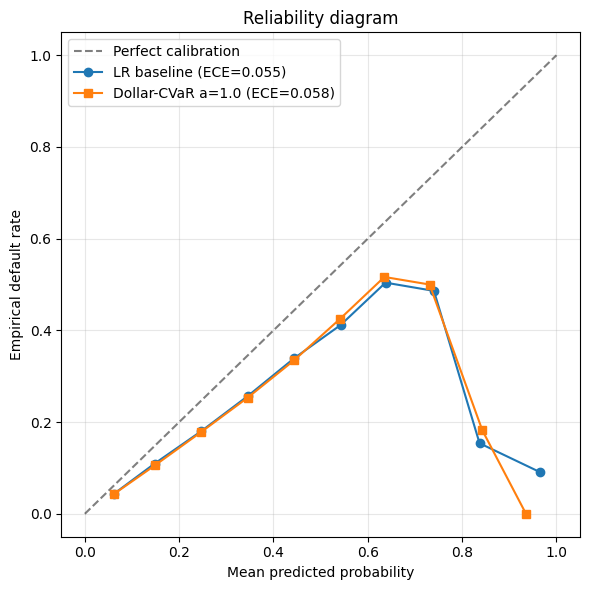

ece -- lr 0.0552, dollar-cvar 0.0576


In [77]:
# reliability diagram and ece
def reliability(y_true, y_prob, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.digitize(y_prob, edges) - 1
    idx = np.clip(idx, 0, n_bins - 1)
    mean_pred, mean_true, weight = [], [], []
    for b in range(n_bins):
        m = idx == b
        if m.sum() == 0:
            mean_pred.append(np.nan); mean_true.append(np.nan); weight.append(0)
        else:
            mean_pred.append(y_prob[m].mean())
            mean_true.append(y_true[m].mean())
            weight.append(m.mean())
    mean_pred = np.array(mean_pred); mean_true = np.array(mean_true); weight = np.array(weight)
    valid = ~np.isnan(mean_pred)
    # ece is the bin-weighted gap between predicted and actual
    ece = np.sum(weight[valid] * np.abs(mean_pred[valid] - mean_true[valid]))
    return mean_pred, mean_true, ece

# refit dollar-cvar at the best es@5% alpha
best_idx = int(np.argmax([m["es5"] for m in results_weighted]))
best_alpha = alpha_values[best_idx]
print(f"best dollar-cvar alpha by es@5%: {best_alpha}")
theta_best, eta_best, _ = sgd_cvar_w(X_tr_b, y_train, alpha=best_alpha,
                                     weights=w_train, n_epochs=20, batch_size=4096,
                                     theta_init=theta_warm)
y_prob_best = sigmoid(X_te_b @ theta_best)

mp_lr, mt_lr, ece_lr = reliability(y_test, y_prob_te_bs)
mp_cv, mt_cv, ece_cv = reliability(y_test, y_prob_best)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
plt.plot(mp_lr, mt_lr, "o-", label=f"LR baseline (ECE={ece_lr:.3f})")
plt.plot(mp_cv, mt_cv, "s-", label=f"Dollar-CVaR a={best_alpha} (ECE={ece_cv:.3f})")
plt.xlabel("Mean predicted probability"); plt.ylabel("Empirical default rate")
plt.title("Reliability diagram"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("calibration.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"ece -- lr {ece_lr:.4f}, dollar-cvar {ece_cv:.4f}")

## Error analysis
Profiling the high-dollar defaults that one model ranks in its top decile and the other misses, to see where the dollar weighting changes the call.

In [78]:
# big-dollar defaults that one model's top decile catches and the other misses
n_test = len(y_test)
k = int(np.ceil(0.10 * n_test))
top_lr = set(np.argsort(y_prob_te_bs)[::-1][:k])
top_cv = set(np.argsort(y_prob_best)[::-1][:k])

# actual defaults with above-median loss
defaulted = (y_test == 1)
big_loss_thresh = np.median(dl_test[defaulted])
big_default = defaulted & (dl_test > big_loss_thresh)

big_idx = np.where(big_default)[0]
caught_by_cv_only = [i for i in big_idx if i in top_cv and i not in top_lr]
caught_by_lr_only = [i for i in big_idx if i in top_lr and i not in top_cv]

print(f"high-dollar defaults (loss > ${big_loss_thresh:,.0f}): {big_default.sum()}")
print(f"  caught by dollar-cvar only: {len(caught_by_cv_only)}")
print(f"  caught by lr only: {len(caught_by_lr_only)}")

# profile the ones only dollar-cvar caught
test_rows = df_raw[test_mask].reset_index(drop=True)
profile_cols = [c for c in ["grade", "loan_amnt", "int_rate", "dti",
                            "annual_inc", "term", "purpose"] if c in test_rows.columns]
if caught_by_cv_only:
    print(test_rows.iloc[caught_by_cv_only][profile_cols].describe(include="all").T)

high-dollar defaults (loss > $12,362): 4437
  caught by dollar-cvar only: 64
  caught by lr only: 61
           count unique         top freq          mean           std      min  \
grade         64      5           C   32           NaN           NaN      NaN   
loan_amnt   64.0    NaN         NaN  NaN   27191.40625   8051.843694  14400.0   
int_rate    64.0    NaN         NaN  NaN     17.134062      3.526765    10.42   
dti         63.0    NaN         NaN  NaN     10.195397      7.815651      0.0   
annual_inc  64.0    NaN         NaN  NaN  81431.171875  42189.784598      0.0   
term          64      2   60 months   46           NaN           NaN      NaN   
purpose       64      9       other   17           NaN           NaN      NaN   

                25%      50%      75%       max  
grade           NaN      NaN      NaN       NaN  
loan_amnt   20000.0  28500.0  35000.0   40000.0  
int_rate      15.04    16.08    18.45     28.72  
dti             3.4     8.79   16.155     29.85  


## Large-loan subsegment
Restricting to the top quartile of funded amount and checking whether dollar-cvar's lead over the baseline widens, which is the direct test of the mechanism.

In [79]:
# top quartile of funded amount where the weighting should pay off
q75 = np.quantile(funded_test, 0.75)
big = funded_test >= q75
print(f"large-loan subsegment: funded >= ${q75:,.0f} ({big.sum():,} of {big.size:,}, {big.mean():.0%})")

def subseg_row(name, y_prob_full):
    yp = y_prob_full[big]
    return {
        "model": name,
        "auc":     roc_auc_score(y_test[big], yp),
        "es5_big": expected_shortfall(y_test[big], yp, dl_test[big]),
        "dwr_big": dollar_weighted_recall(y_test[big], yp, dl_test[big]),
    }

best_a = alpha_values[int(np.argmax([m["es5"] for m in results_weighted]))]
seg_rows = [
    subseg_row("LR baseline",             y_prob_te_bs),
    subseg_row("Cost-sensitive LR",       y_prob_cs),
    subseg_row("Dollar-CVaR a=1.0",       dollar_cvar_preds[1.0]),
    subseg_row(f"Dollar-CVaR a={best_a}", dollar_cvar_preds[best_a]),
]
seg_df = pd.DataFrame(seg_rows).set_index("model")
disp = seg_df.copy()
disp["es5_big"] = disp["es5_big"].map("${:,.0f}".format)
disp["dwr_big"] = disp["dwr_big"].map("{:.1%}".format)
disp["auc"]     = disp["auc"].map("{:.3f}".format)
print(disp.to_string())

# compare the lift on the subsegment against the full test set
full_lift = max(m["es5"] for m in results_weighted) - baseline_metrics["es5"]
seg_lift  = seg_df["es5_big"].max() - seg_df.loc["LR baseline", "es5_big"]
print(f"es@5% lift over lr -- full ${full_lift:,.0f}, large-loan ${seg_lift:,.0f}")

large-loan subsegment: funded >= $20,000 (16,983 of 56,318, 30%)
                     auc  es5_big dwr_big
model                                    
LR baseline        0.699  $10,484   19.7%
Cost-sensitive LR  0.705  $10,840   20.6%
Dollar-CVaR a=1.0  0.704  $10,856   20.6%
Dollar-CVaR a=1.0  0.704  $10,856   20.6%
es@5% lift over lr -- full $65, large-loan $372


## Approved-book loss
The lender's view, closer to the training objective than the ranking metrics: approve the safest loans at a fixed rate and measure the dollar loss that leaks in from approved loans that defaulted.

Two numbers, the total leaked loss (which tracks dwr at the matching threshold) and the cvar of the leaked per-loan losses (which catches whether the few biggest losses slip through, and isn't a transform of dwr).

In [80]:
# leaked loss is the total dollars from approved (safest) loans that defaulted at a fixed approval rate
def approved_book_loss(y_prob, dollar_loss, approval_rate):
    n = len(y_prob)
    n_approve = int(np.floor(approval_rate * n))
    approved = np.argsort(y_prob)[:n_approve]       # lowest predicted risk gets approved
    return dollar_loss[approved].sum()

# cvar of the per-loan leaked losses which catches whether the biggest ones slip through
def approved_tail_loss(y_prob, dollar_loss, approval_rate, tail=0.05):
    n = len(y_prob)
    n_approve = int(np.floor(approval_rate * n))
    approved = np.argsort(y_prob)[:n_approve]
    losses = dollar_loss[approved]
    losses = losses[losses > 0]                     # only the realized losses
    if len(losses) == 0:
        return 0.0
    k = max(1, int(np.ceil(tail * len(losses))))
    return np.sort(losses)[::-1][:k].mean()

models_eval = {
    "LR baseline":       y_prob_te_bs,
    "Cost-sensitive LR": y_prob_cs,
    "Dollar-CVaR a=1.0": dollar_cvar_preds[1.0],
}
best_a = alpha_values[int(np.argmax([m["es5"] for m in results_weighted]))]
if best_a != 1.0:
    models_eval[f"Dollar-CVaR a={best_a}"] = dollar_cvar_preds[best_a]

rates = [0.70, 0.80, 0.90]
rows = []
for name, yp in models_eval.items():
    row = {"model": name}
    for r in rates:
        row[f"leak@{int(r*100)}%"] = approved_book_loss(yp, dl_test, r)
    row["tailCVaR@80%"] = approved_tail_loss(yp, dl_test, 0.80)
    rows.append(row)
leak_df = pd.DataFrame(rows).set_index("model")

disp = leak_df.copy()
for c in [f"leak@{int(r*100)}%" for r in rates]:
    disp[c] = disp[c].map(lambda v: f"${v/1e6:,.2f}M")
disp["tailCVaR@80%"] = disp["tailCVaR@80%"].map("${:,.0f}".format)
print(disp.to_string())

base_leak = approved_book_loss(y_prob_te_bs, dl_test, 0.80)
dcv_leak  = approved_book_loss(dollar_cvar_preds[1.0], dl_test, 0.80)
base_tail = approved_tail_loss(y_prob_te_bs, dl_test, 0.80)
dcv_tail  = approved_tail_loss(dollar_cvar_preds[1.0], dl_test, 0.80)
print(f"at 80% approval, dollar-cvar a=1.0 vs lr:")
print(f"  total leaked: ${base_leak-dcv_leak:,.0f} less ({(base_leak-dcv_leak)/base_leak:+.2%})")
print(f"  worst-case (cvar) leaked: ${base_tail-dcv_tail:,.0f} less per loan")

                  leak@70% leak@80% leak@90% tailCVaR@80%
model                                                    
LR baseline        $50.50M  $68.28M  $90.34M      $35,585
Cost-sensitive LR  $50.58M  $68.48M  $90.37M      $35,424
Dollar-CVaR a=1.0  $50.60M  $68.22M  $90.11M      $35,424
at 80% approval, dollar-cvar a=1.0 vs lr:
  total leaked: $58,966 less (+0.09%)
  worst-case (cvar) leaked: $161 less per loan


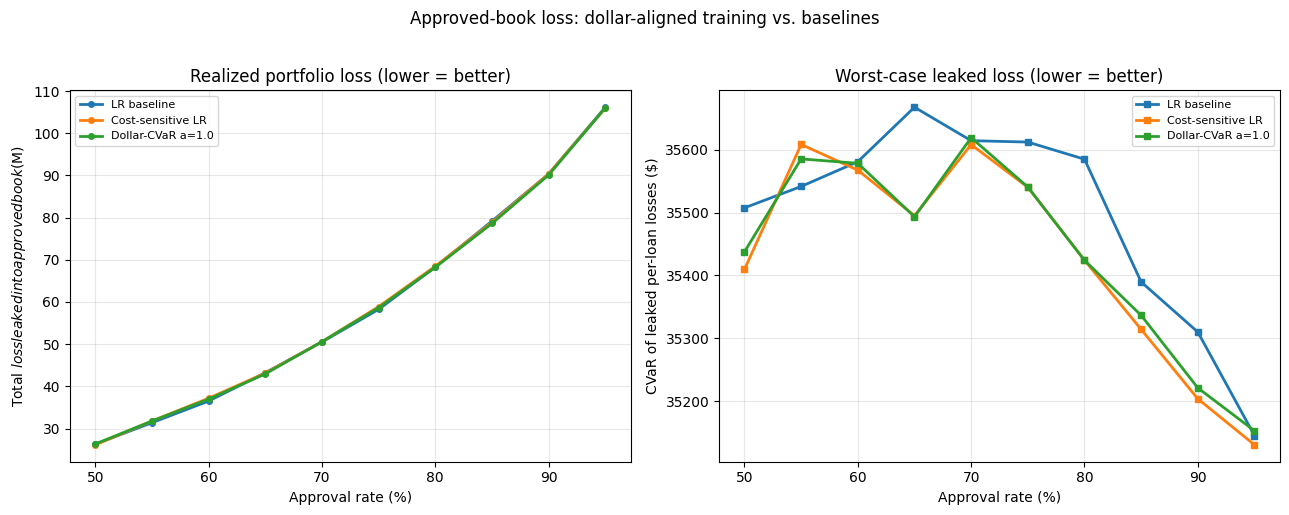

In [81]:
# leaked loss and worst-case leaked loss swept across approval rates
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
rate_grid = np.linspace(0.50, 0.95, 10)

for name, yp in models_eval.items():
    leaks = [approved_book_loss(yp, dl_test, r) / 1e6 for r in rate_grid]
    axL.plot(rate_grid * 100, leaks, "o-", label=name, lw=2, ms=4)
axL.set_xlabel("Approval rate (%)"); axL.set_ylabel("Total $ loss leaked into approved book ($M)")
axL.set_title("Realized portfolio loss (lower = better)")
axL.legend(fontsize=8); axL.grid(True, alpha=0.3)

for name, yp in models_eval.items():
    tails = [approved_tail_loss(yp, dl_test, r) for r in rate_grid]
    axR.plot(rate_grid * 100, tails, "s-", label=name, lw=2, ms=4)
axR.set_xlabel("Approval rate (%)"); axR.set_ylabel("CVaR of leaked per-loan losses ($)")
axR.set_title("Worst-case leaked loss (lower = better)")
axR.legend(fontsize=8); axR.grid(True, alpha=0.3)

fig.suptitle("Approved-book loss: dollar-aligned training vs. baselines", y=1.02)
plt.tight_layout()
plt.savefig("approved_book_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Paired bootstrap
Margins are small, so we resample the test set with replacement (B=500) using the same indices across models each draw and recompute the metric difference. A 95% CI that misses zero is significant at 5%.

In [82]:
# paired bootstrap of dollar-cvar a=1.0 vs lr reusing the same resampled indices for both each draw
rng_bs = np.random.default_rng(RANDOM_SEED)
B = 500
r_eval = 0.80
n_te = len(y_test)

def _leak_total(yp, dl, idx, r):
    n_a = int(np.floor(r * len(idx)))
    order = idx[np.argsort(yp[idx])]
    return dl[order[:n_a]].sum()

def _es5(yp, dl, idx, alpha=0.05):
    k = max(1, int(np.ceil(alpha * len(idx))))
    order = idx[np.argsort(yp[idx])[::-1]]
    return dl[order[:k]].mean()

base_yp, dcv_yp = y_prob_te_bs, dollar_cvar_preds[1.0]
d_leak, d_es = [], []
for _ in range(B):
    idx = rng_bs.integers(0, n_te, size=n_te)
    # lr minus dcvar so positive means dollar-cvar leaks less
    d_leak.append(_leak_total(base_yp, dl_test, idx, r_eval) - _leak_total(dcv_yp, dl_test, idx, r_eval))
    # dcvar minus lr so positive means dollar-cvar captures more tail dollars
    d_es.append(_es5(dcv_yp, dl_test, idx) - _es5(base_yp, dl_test, idx))
d_leak, d_es = np.array(d_leak), np.array(d_es)

def _report(name, arr, unit="$"):
    lo, hi = np.percentile(arr, [2.5, 97.5])
    sig = "significant" if (lo > 0 or hi < 0) else "not significant (CI includes 0)"
    print(f"  {name}: mean {unit}{arr.mean():,.0f}, 95% CI [{unit}{lo:,.0f}, {unit}{hi:,.0f}] -> {sig}")

print(f"paired bootstrap (B={B}) at {int(r_eval*100)}% approval, dollar-cvar a=1.0 vs lr:")
_report("leaked-loss reduction (lr - dcvar)", d_leak)
_report("es@5% improvement (dcvar - lr)", d_es)

paired bootstrap (B=500) at 80% approval, dollar-cvar a=1.0 vs lr:
  leaked-loss reduction (lr - dcvar): mean $57,739, 95% CI [$-537,032, $632,594] -> not significant (CI includes 0)
  es@5% improvement (dcvar - lr): mean $107, 95% CI [$-52, $273] -> not significant (CI includes 0)


## Frontier figures
The two tail metrics against alpha for both objectives with the baseline as a reference line. Es@5% on the left, dollar-weighted recall in the top decile on the right.

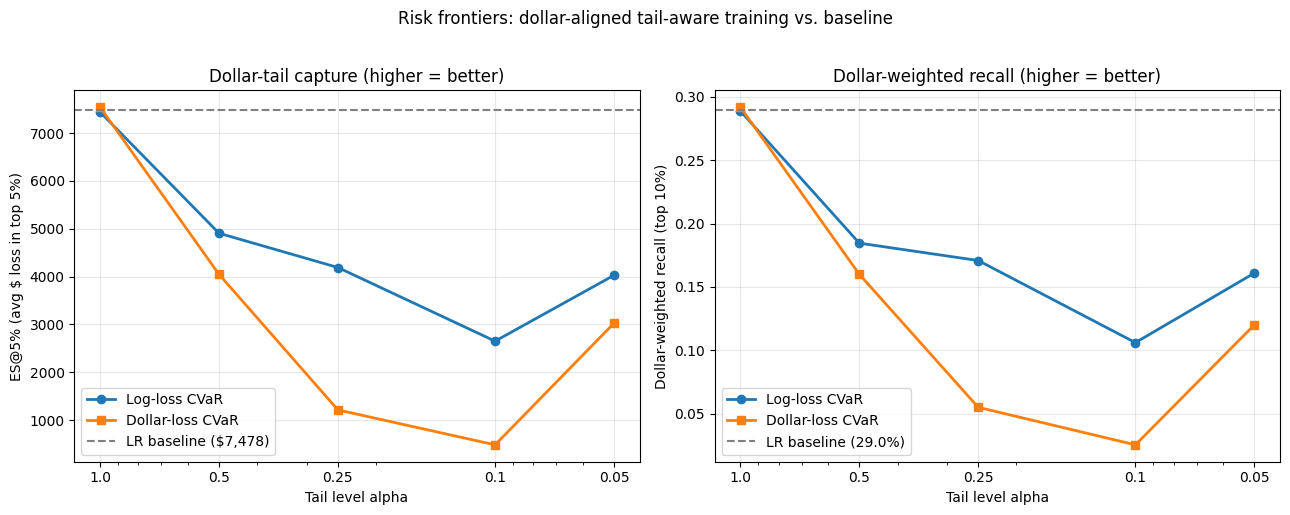

In [83]:
# es@5% on the left and dwr on the right vs alpha for both objectives with the baseline as a dashed line
es_logloss  = [m["es5"] for m in results_log[1:]]     # index 0 is the baseline so skip it
es_weighted = [m["es5"] for m in results_weighted]
dwr_logloss = [m["dwr"] for m in results_log[1:]]
dwr_weighted= [m["dwr"] for m in results_weighted]
base_es  = results_log[0]["es5"]
base_dwr = results_log[0]["dwr"]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

axL.plot(alpha_values, es_logloss,  "o-", label="Log-loss CVaR", lw=2)
axL.plot(alpha_values, es_weighted, "s-", label="Dollar-loss CVaR", lw=2)
axL.axhline(base_es, ls="--", color="gray", label=f"LR baseline (${base_es:,.0f})")
axL.set_xlabel("Tail level alpha"); axL.set_ylabel("ES@5% (avg $ loss in top 5%)")
axL.set_title("Dollar-tail capture (higher = better)")
axL.legend(loc="lower left"); axL.grid(True, alpha=0.3)
axL.set_xscale("log"); axL.set_xticks(alpha_values); axL.set_xticklabels([str(a) for a in alpha_values])
axL.invert_xaxis()

axR.plot(alpha_values, dwr_logloss,  "o-", label="Log-loss CVaR", lw=2)
axR.plot(alpha_values, dwr_weighted, "s-", label="Dollar-loss CVaR", lw=2)
axR.axhline(base_dwr, ls="--", color="gray", label=f"LR baseline ({base_dwr:.1%})")
axR.set_xlabel("Tail level alpha"); axR.set_ylabel("Dollar-weighted recall (top 10%)")
axR.set_title("Dollar-weighted recall (higher = better)")
axR.legend(loc="lower left"); axR.grid(True, alpha=0.3)
axR.set_xscale("log"); axR.set_xticks(alpha_values); axR.set_xticklabels([str(a) for a in alpha_values])
axR.invert_xaxis()

fig.suptitle("Risk frontiers: dollar-aligned tail-aware training vs. baseline", y=1.02)
plt.tight_layout()
plt.savefig("alpha_frontier.png", dpi=150, bbox_inches="tight")
plt.show()

## Full results table
Every model on auc, f1, es@5%, dwr, saved to final_results.csv.

In [84]:
# everything in one table saved to csv
all_results = (
    [results_log[0]]                       # lr baseline
    + results_log[1:]                      # log-loss cvar sweep
    + results_weighted                     # dollar-loss cvar sweep
    + [cs_metrics, gda_metrics, qda_metrics, qda_pca_metrics, rf_metrics]
)
final_df = pd.DataFrame(all_results).set_index("model")
display_df = final_df.copy()
display_df["es5"] = display_df["es5"].map("${:,.0f}".format)
display_df["dwr"] = display_df["dwr"].map("{:.1%}".format)
display_df["auc"] = display_df["auc"].map("{:.3f}".format)
display_df["f1"]  = display_df["f1"].map("{:.3f}".format)
print(display_df.to_string())

final_df.to_csv("final_results.csv")
print("saved final_results.csv")

                                       auc     f1     es5    dwr
model                                                           
LR test (2018)                       0.719  0.172  $7,478  29.0%
CVaR-Logistic alpha=1.0              0.717  0.187  $7,443  28.9%
CVaR-Logistic alpha=0.5              0.600  0.035  $4,907  18.5%
CVaR-Logistic alpha=0.25             0.592  0.222  $4,190  17.1%
CVaR-Logistic alpha=0.1              0.462  0.192  $2,649  10.6%
CVaR-Logistic alpha=0.05             0.584  0.219  $4,028  16.1%
Dollar-CVaR alpha=1.0                0.719  0.176  $7,543  29.2%
Dollar-CVaR alpha=0.5                0.677  0.175  $4,048  16.0%
Dollar-CVaR alpha=0.25               0.549  0.252  $1,211   5.5%
Dollar-CVaR alpha=0.1                0.494  0.252    $480   2.5%
Dollar-CVaR alpha=0.05               0.616  0.299  $3,026  12.0%
Cost-Sensitive LR (funded-weighted)  0.720  0.174  $7,538  29.0%
GDA (shared covariance)              0.717  0.204  $7,245  27.5%
QDA (per-class cov, full-

## Headline
Quick summary for the writeup, where dollar-cvar lands against the baselines and the approved-book number at 80% approval.

In [85]:
# quick headline for the writeup
def _es(m): return m["es5"]
baseline_es  = baseline_metrics["es5"]
cs_es        = cs_metrics["es5"]
best_dollar  = max(results_weighted, key=_es)
best_dwr_mod = max(results_weighted, key=lambda m: m["dwr"])

print(f"lr baseline es@5%:        ${baseline_es:,.0f}")
print(f"cost-sensitive lr es@5%:  ${cs_es:,.0f}")
print(f"best dollar-cvar [{best_dollar['model']}]: ${best_dollar['es5']:,.0f}")
if best_dollar["es5"] >= max(baseline_es, cs_es):
    print(f"  +${best_dollar['es5']-baseline_es:,.0f} over lr, +${best_dollar['es5']-cs_es:,.0f} over cost-sensitive lr")
print(f"best dwr: {best_dwr_mod['model']} at {best_dwr_mod['dwr']:.1%} (baseline {baseline_metrics['dwr']:.1%})")

# approved-book number at 80%
try:
    _bl = approved_book_loss(y_prob_te_bs, dl_test, 0.80)
    _dl = approved_book_loss(dollar_cvar_preds[1.0], dl_test, 0.80)
    print(f"approved-book leak @80%: dollar-cvar a=1.0 leaks ${_bl-_dl:,.0f} ({(_bl-_dl)/_bl:+.2%}) vs lr")
except NameError:
    pass

lr baseline es@5%:        $7,478
cost-sensitive lr es@5%:  $7,538
best dollar-cvar [Dollar-CVaR alpha=1.0]: $7,543
  +$65 over lr, +$5 over cost-sensitive lr
best dwr: Dollar-CVaR alpha=1.0 at 29.2% (baseline 29.0%)
approved-book leak @80%: dollar-cvar a=1.0 leaks $58,966 (+0.09%) vs lr
